In [6]:
#Now, let's build up to a simple chain that combines 4 concepts.

#Using chat messages as our graph state
#Using chat models in graph nodes
#Binding tools to our chat model
#Executing tool calls in graph nodes


In [7]:
#Chat models can use messages, which capture different roles within a conversation.

#LangChain supports various message types, including HumanMessage, AIMessage, SystemMessage, and ToolMessage.

#These represent a message from the user, from chat model, for the chat model to instruct behavior, and from a tool call.

#Let's create a list of messages.

#Each message can be supplied with a few things:

#content - content of the message
#name - optionally, a message author
#response_metadata - optionally, a dict of metadata (e.g., often populated by model provider for AIMessages)

In [8]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage

messages = [AIMessage(content=f"So you said you were researching ocean mammals?", name="Model")]
messages.append(HumanMessage(content=f"Yes, that's right.",name="Lance"))
messages.append(AIMessage(content=f"Great, what would you like to learn about.", name="Model"))
messages.append(HumanMessage(content=f"I want to learn about the best place to see Orcas in the US.", name="Lance"))

for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Model

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, that's right.
================================== Ai Message ==================================
Name: Model

Great, what would you like to learn about.
================================ Human Message =================================
Name: Lance

I want to learn about the best place to see Orcas in the US.


In [9]:
#Chat Models
#Chat models use a sequence of messages as input and support message types, as discussed above.

#There are many to choose from! Let's work with OpenAI.

#Let's check that your OPENAI_API_KEY is set and, if not, you will be asked to enter it.

In [10]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("OPENAI_API_KEY")

OPENAI_API_KEY:  ········


In [11]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4o")
result = llm.invoke(messages)
type(result)

langchain_core.messages.ai.AIMessage

In [12]:
result

AIMessage(content="If you're looking to see orcas in the United States, the Pacific Northwest is one of the best places to go. The San Juan Islands in Washington State, particularly around the towns of Friday Harbor and Roche Harbor, are renowned for orca sightings. The waters around these islands are home to several pods of Southern Resident orcas, especially during the spring and summer months.\n\nAnother excellent location is the waters of Puget Sound and the Strait of Juan de Fuca, where orcas often hunt for salmon. Additionally, areas near Seattle and the western coast of Washington also offer opportunities for sightings.\n\nOrganized whale-watching tours from Seattle, Bellingham, and the San Juan Islands can increase your chances of seeing orcas, as experienced guides know the best spots and times to find them.\n\nKeep in mind that while orca sightings are common, they are wild animals, so sightings can't be completely guaranteed.", additional_kwargs={'refusal': None}, response_m

In [13]:
result.response_metadata

{'token_usage': {'completion_tokens': 181,
  'prompt_tokens': 67,
  'total_tokens': 248,
  'completion_tokens_details': {'accepted_prediction_tokens': 0,
   'audio_tokens': 0,
   'reasoning_tokens': 0,
   'rejected_prediction_tokens': 0},
  'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}},
 'model_provider': 'openai',
 'model_name': 'gpt-4o-2024-08-06',
 'system_fingerprint': 'fp_d87ad9333a',
 'id': 'chatcmpl-DQOiZ7Or3QXXla874cxhpmEy6z0ay',
 'service_tier': 'default',
 'finish_reason': 'stop',
 'logprobs': None}

In [14]:
#Tools
#Tools are useful whenever you want a model to interact with external systems.

#External systems (e.g., APIs) often require a particular input schema or payload, rather than natural language.

#When we bind an API, for example, as a tool we given the model awareness of the required input schema.

#The model will choose to call a tool based upon the natural language input from the user.

#And, it will return an output that adheres to the tool's schema.

#Many LLM providers support tool calling and tool calling interface in LangChain is simple.

#You can simply pass any Python function into ChatModel.bind_tools(function).

In [15]:
#Let's showcase a simple example of tool calling!

#The multiply function is our tool.
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

llm_with_tools = llm.bind_tools([multiply])

In [16]:
tool_call = llm_with_tools.invoke([HumanMessage(content=f"What is 2 multiplied by 3", name="Lance")])

In [17]:
tool_call.tool_calls

[{'name': 'multiply',
  'args': {'a': 2, 'b': 3},
  'id': 'call_PGHS5a7yWEME3jmwmapU0qui',
  'type': 'tool_call'}]

In [18]:
#Using messages as state
#With these foundations in place, we can now use messages in our graph state.

#Let's define our state, MessagesState, as a TypedDict with a single key: messages.

#messages is simply a list of messages, as we defined above (e.g., HumanMessage, etc).

from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage

class MessagesState(TypedDict):
    messages: list[AnyMessage]

In [19]:
#Reducers
#Now, we have a minor problem!

#As we discussed, each node will return a new value for our state key messages.

#But, this new value will overwrite the prior messages value!

#As our graph runs, we want to append messages to our messages state key.

#We can use reducer functions to address this.

#Reducers specify how state updates are performed.

#If no reducer function is specified, then it is assumed that updates to the key should override it as we saw before.

#But, to append messages, we can use the pre-built add_messages reducer.

#This ensures that any messages are appended to the existing list of messages.

#We simply need to annotate our messages key with the add_messages reducer function as metadata.

from typing import Annotated
from langgraph.graph.message import add_messages

class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [20]:
#Since having a list of messages in graph state is so common, LangGraph has a pre-built MessagesState!

#MessagesState is defined:

#With a pre-build single messages key
#This is a list of AnyMessage objects
#It uses the add_messages reducer
#We'll usually use MessagesState because it is less verbose than defining a custom TypedDict, as shown above.

from langgraph.graph import MessagesState

class MessagesState(MessagesState):
    # Add any keys needed beyond messages, which is pre-built 
    pass

In [21]:
#To go a bit deeper, we can see how the add_messages reducer works in isolation.
# Initial state
initial_messages = [AIMessage(content="Hello! How can I assist you?", name="Model"),
                    HumanMessage(content="I'm looking for information on marine biology.", name="Lance")
                   ]

# New message to add
new_message = AIMessage(content="Sure, I can help with that. What specifically are you interested in?", name="Model")

# Test
add_messages(initial_messages , new_message)

[AIMessage(content='Hello! How can I assist you?', additional_kwargs={}, response_metadata={}, name='Model', id='20a9c22a-0ae9-4eb8-9195-7d549d2829f3', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content="I'm looking for information on marine biology.", additional_kwargs={}, response_metadata={}, name='Lance', id='caecdfe0-63af-47c7-86ae-0e07b41f48f9'),
 AIMessage(content='Sure, I can help with that. What specifically are you interested in?', additional_kwargs={}, response_metadata={}, name='Model', id='6467939a-a4e9-4967-8bfb-f83626187fa4', tool_calls=[], invalid_tool_calls=[])]

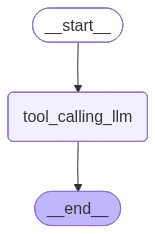

In [22]:
#Our graph
#Now, lets use MessagesState with a graph.

from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
    
# Node
def tool_calling_llm(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_edge(START, "tool_calling_llm")
builder.add_edge("tool_calling_llm", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [23]:
#If we pass in Hello!, the LLM responds without any tool calls.
messages = graph.invoke({"messages": HumanMessage(content="Hello!")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello!
================================== Ai Message ==================================

Hello! How can I assist you today?


In [24]:
#The LLM chooses to use a tool when it determines that the input or task requires the functionality provided by that tool.
messages = graph.invoke({"messages": HumanMessage(content="Multiply 2 and 3")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (call_XyARzaMZuDPDOWcQ7liZgx3A)
 Call ID: call_XyARzaMZuDPDOWcQ7liZgx3A
  Args:
    a: 2
    b: 3
